# Logistic Regression
- Binary Classification

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, roc_curve, roc_auc_score, confusion_matrix
from sklearn.linear_model import LogisticRegression

In [2]:
df = pd.read_csv('heart.csv')
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [3]:
# features and target
x = df.iloc[:, 0: -1]
y = df.iloc[:, -1]

# split
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2, random_state=42)

In [6]:
# hyperparameter tuning

param_grid = [
    {
        'penalty': ['l1', 'l2'],
        'C': [0.01, 0.1, 1, 10, 100],
        'solver': ['liblinear'],
        'class_weight': [None, 'balanced'],
        'max_iter': [100, 500, 1000]
    },
    {
        'penalty': ['l1', 'l2'],
        'C': [0.01, 0.1, 1, 10, 100],
        'solver': ['saga'],
        'class_weight': [None, 'balanced'],
        'max_iter': [100, 500, 1000]
    },
    {
        'penalty': ['l2'],
        'C': [0.01, 0.1, 1, 10, 100],
        'solver': ['lbfgs', 'newton-cg'],
        'class_weight': [None, 'balanced'],
        'max_iter': [100, 500, 1000]
    }
]

grid = GridSearchCV(estimator = LogisticRegression(),
                    param_grid = param_grid,
                    cv = 5,
                    scoring = 'accuracy',
                    n_jobs = -1)

grid.fit(x_train, y_train)

print('👉 best parameters : ',grid.best_params_)
print('👉 best score : ',grid.best_score_)
print('👉 best estimator : ',grid.best_estimator_)

👉 best parameters :  {'C': 1, 'class_weight': None, 'max_iter': 100, 'penalty': 'l2', 'solver': 'liblinear'}
👉 best score :  0.8263605442176871
👉 best estimator :  LogisticRegression(C=1, solver='liblinear')


In [13]:
# feature reduction
best_model = grid.best_estimator_

feature_imp = pd.DataFrame({
    'Feature': x_train.columns,
    'Coefficient': best_model.coef_[0],
    'Importance': abs(best_model.coef_[0])
})

feature_imp = feature_imp.sort_values(
    by='Importance',
    ascending=False
)

feature_imp

,Feature,Coefficient,Importance
1,sex,-1.354776,1.354776
8,exang,-0.890850,0.890850
12,thal,-0.857964,0.857964
2,cp,0.789434,0.789434
11,ca,-0.770627,0.770627
10,slope,0.661624,0.661624
9,oldpeak,-0.614409,0.614409
6,restecg,0.521659,0.521659
5,fbs,0.128340,0.128340
7,thalach,0.025962,0.025962


In [12]:
selected_features = feature_imp[feature_imp['Importance'] >= 0.128340]['Feature']
selected_features

,Feature
1,sex
8,exang
12,thal
2,cp
11,ca
10,slope
9,oldpeak
6,restecg
5,fbs


In [16]:
x_reduced = df[selected_features]

# split
x_trainr, x_testr, y_trainr, y_testr = train_test_split(x_reduced, y, test_size=0.2, random_state = 42)

In [17]:
# Model train
final_model = LogisticRegression(**grid.best_params_)
final_model.fit(x_trainr, y_trainr)

LogisticRegression(C=1, solver='liblinear')

In [19]:
y_Pred = final_model.predict(x_testr)

✅ Accuracy :  0.819672131147541




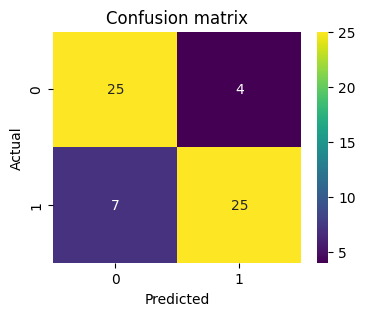

In [27]:
# evaluation
print('✅ Accuracy : ',accuracy_score(y_testr, y_Pred))
print('\n')

plt.figure(figsize = (4,3))
sns.heatmap(confusion_matrix(y_testr, y_Pred), annot = True, cmap = 'viridis')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion matrix')
plt.show()


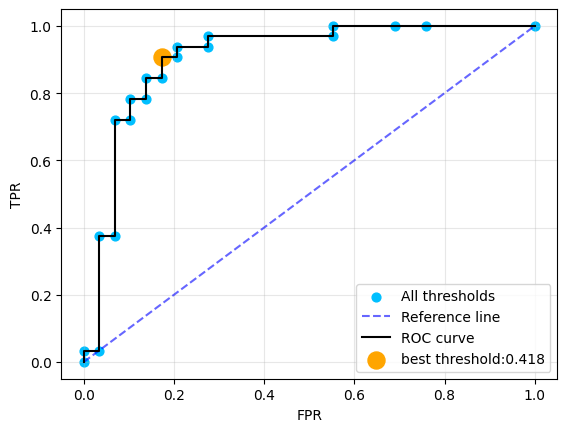

In [40]:
# ROC Curve
y_score = final_model.predict_proba(x_testr)[:, 1]
fpr, tpr, thresholds = roc_curve(y_testr, y_score)

# optimal threshold
optimal_idx = np.argmax(tpr - fpr)
optimal_threshold = thresholds[optimal_idx]


plt.scatter(fpr, tpr, color = 'deepskyblue', s = 40, label = 'All thresholds')
plt.plot([0,1],[0,1], color = 'blue', alpha = 0.6, ls = 'dashed', label = 'Reference line')
plt.plot(fpr, tpr, color = 'k', label = 'ROC curve')
plt.scatter(fpr[optimal_idx], tpr[optimal_idx], color = 'orange', s = 150, label = f'best threshold:{optimal_threshold:.3f}')
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.legend()
plt.grid(True, alpha = 0.3)
plt.show()
